In [ ]:
from google.colab import files
import io

uploaded = files.upload()
uploaded

In [1]:
#Pacotes a serem usados
import pandas as pd
from sklearn import metrics
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
import plotly.express as px
import plotly.graph_objects as go
import pickle
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from yellowbrick.classifier import ConfusionMatrix
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sys
assert sys.version_info >= (3, 5)
import sklearn
assert sklearn.__version__ >= "0.20"
import numpy as np
import os
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)
PROJECT_ROOT_DIR = "."
CHAPTER_ID = "end_to_end_project"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)
os.makedirs(IMAGES_PATH, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

In [2]:
# Modelo de classificação
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

**Modelo de Classificação - Exercício de Crédito**


Para Júlio - Eu alterei a base, porque estava tendo problemas dos pontos com as vírgulas, então se for rodar o código usar a base desse link --> https://drive.google.com/file/d/1lr3UVE1iDcLNyexgAGi3Q0z50nKThUKp/view?usp=sharing. Achei que era mais fácil consertar direito na base, do que ter que converter pelo python

In [ ]:
import io
df2 = pd.read_csv(io.BytesIO(uploaded['exercicio_cred.csv']), sep =';')
df2.tail(5)

,idade,experiencia,tempo_endereco,renda,debito_renda,cred_deb,outros_debitos,default
4995,36,4,15,24.9,12.37,1.219731,1.860399,0
4996,46,3,20,22.1,6.99,0.670439,0.874351,0
4997,31,3,3,18.7,24.80,2.017356,2.620244,1
4998,48,14,19,38.2,7.12,0.369898,2.349942,0
4999,44,20,0,71.7,2.50,0.623790,1.168710,0


In [ ]:
print(df2.info())
print(df2.head())
print(df2.tail())
df2.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   idade           5000 non-null   int64  
 1   experiencia     5000 non-null   int64  
 2   tempo_endereco  5000 non-null   int64  
 3   renda           5000 non-null   float64
 4   debito_renda    5000 non-null   float64
 5   cred_deb        5000 non-null   float64
 6   outros_debitos  5000 non-null   float64
 7   default         5000 non-null   int64  
dtypes: float64(4), int64(4)
memory usage: 312.6 KB
None
   idade  experiencia  tempo_endereco  renda  debito_renda  cred_deb  \
0     41           17              12   35.9         11.90  0.504108   
1     30           13               8   46.7         17.88  1.352694   
2     40           15              14   61.8         10.64  3.438997   
3     41           15              14   72.0         29.67  4.165668   
4     57            7      

(5000, 8)

In [ ]:
display(df2)
df2.describe()

,idade,experiencia,tempo_endereco,renda,debito_renda,cred_deb,outros_debitos,default
0,41,17,12,35.9,11.90,0.504108,3.767992,0
1,30,13,8,46.7,17.88,1.352694,6.997266,0
2,40,15,14,61.8,10.64,3.438997,3.136523,0
3,41,15,14,72.0,29.67,4.165668,17.196732,0
4,57,7,37,25.6,15.86,1.498199,2.561961,0
...,...,...,...,...,...,...,...,...
4995,36,4,15,24.9,12.37,1.219731,1.860399,0
4996,46,3,20,22.1,6.99,0.670439,0.874351,0
4997,31,3,3,18.7,24.80,2.017356,2.620244,1
4998,48,14,19,38.2,7.12,0.369898,2.349942,0


,idade,experiencia,tempo_endereco,renda,debito_renda,cred_deb,outros_debitos,default
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,35.387200,8.703800,8.154000,47.676980,10.075984,1.628071,3.218582,0.251200
std,7.948403,7.194583,6.760786,51.793192,6.659336,3.053369,6.944523,0.433747
min,20.000000,0.000000,0.000000,12.100000,0.080000,0.005292,0.009373,0.000000
25%,29.000000,3.000000,3.000000,24.500000,5.050000,0.396181,0.990071,0.000000
50%,35.000000,7.000000,7.000000,34.500000,8.635000,0.906189,1.960223,0.000000
75%,41.000000,13.000000,12.000000,54.725000,13.682500,1.859147,3.789633,1.000000
max,58.000000,38.000000,37.000000,2461.700000,44.620000,139.580605,416.517425,1.000000


In [ ]:
#quantidade de pagadores e não pagadores
np.unique(df2['default'], return_counts=True)

(array([0, 1]), array([3744, 1256]))

In [ ]:
df2.isnull()

,idade,experiencia,tempo_endereco,renda,debito_renda,cred_deb,outros_debitos,default
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
4995,False,False,False,False,False,False,False,False
4996,False,False,False,False,False,False,False,False
4997,False,False,False,False,False,False,False,False
4998,False,False,False,False,False,False,False,False


In [ ]:
df2.isnull().sum()

idade             0
experiencia       0
tempo_endereco    0
renda             0
debito_renda      0
cred_deb          0
outros_debitos    0
default           0
dtype: int64

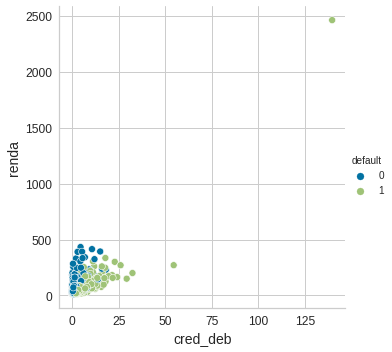

In [ ]:
_ = sns.relplot(x = 'cred_deb', y = 'renda', hue = 'default', data = df2)

In [ ]:
df=df2
#Vamos deletar os dados dos outliers
df2.drop(df2.loc[df2['renda'] > 250].index, inplace=True)
df2.describe()

,idade,experiencia,tempo_endereco,renda,debito_renda,cred_deb,outros_debitos,default
count,4978.000000,4978.000000,4978.000000,4978.000000,4978.000000,4978.000000,4978.000000,4978.000000
mean,35.325231,8.635798,8.128767,46.044556,10.078576,1.559532,3.082363,0.250502
std,7.902338,7.113742,6.733965,34.580133,6.659000,2.130252,3.622486,0.433346
min,20.000000,0.000000,0.000000,12.100000,0.080000,0.005292,0.009373,0.000000
25%,29.000000,3.000000,3.000000,24.500000,5.050000,0.394353,0.987395,0.000000
50%,35.000000,7.000000,7.000000,34.400000,8.655000,0.899000,1.946059,0.000000
75%,41.000000,13.000000,12.000000,54.375000,13.690000,1.841753,3.757794,1.000000
max,58.000000,38.000000,37.000000,248.300000,44.620000,32.368219,53.401521,1.000000


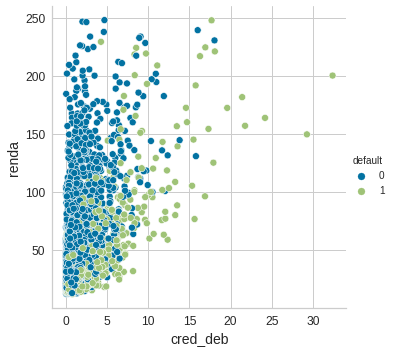

In [ ]:
__ = sns.relplot(x = 'cred_deb', y = 'renda', hue = 'default', data = df)

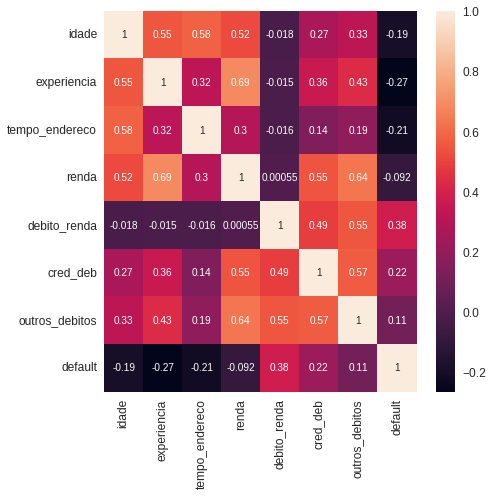

In [ ]:
#Próximo de 1 -> forte correlação, próximo de -1 -> fraca correlação
figura = plt.figure(figsize=(7,7))
sns.heatmap(df.corr(), annot=True);

In [ ]:
grafico = px.scatter_matrix(df, dimensions=['idade', 'experiencia', 'renda'], color = 'default')
grafico.show()
#Há presença de idades negativas

In [ ]:
display(df)

,idade,experiencia,tempo_endereco,renda,debito_renda,cred_deb,outros_debitos,default
0,41,17,12,35.9,11.90,0.504108,3.767992,0
1,30,13,8,46.7,17.88,1.352694,6.997266,0
2,40,15,14,61.8,10.64,3.438997,3.136523,0
3,41,15,14,72.0,29.67,4.165668,17.196732,0
4,57,7,37,25.6,15.86,1.498199,2.561961,0
...,...,...,...,...,...,...,...,...
4995,36,4,15,24.9,12.37,1.219731,1.860399,0
4996,46,3,20,22.1,6.99,0.670439,0.874351,0
4997,31,3,3,18.7,24.80,2.017356,2.620244,1
4998,48,14,19,38.2,7.12,0.369898,2.349942,0


In [ ]:
X_credit = df.iloc[:, 1:7].values
X_credit

array([[17.        , 12.        , 35.9       , 11.9       ,  0.5041078 ,
         3.7679922 ],
       [13.        ,  8.        , 46.7       , 17.88      ,  1.35269352,
         6.99726648],
       [15.        , 14.        , 61.8       , 10.64      ,  3.43899696,
         3.13652304],
       ...,
       [ 3.        ,  3.        , 18.7       , 24.8       ,  2.017356  ,
         2.620244  ],
       [14.        , 19.        , 38.2       ,  7.12      ,  0.36989824,
         2.34994176],
       [20.        ,  0.        , 71.7       ,  2.5       ,  0.62379   ,
         1.16871   ]])

In [ ]:
y_credit = df.iloc[:, 7].values
y_credit

array([0, 0, 0, ..., 1, 0, 0])

In [ ]:
X_credit[:,0].max(), X_credit[:,1].max(), X_credit[:,2].max()

(38.0, 37.0, 248.3)

In [ ]:
X_credit[:,0].min(), X_credit[:,1].min(), X_credit[:,2].min()

(0.0, 0.0, 12.1)

***Treino e Teste***

In [ ]:
#número de matrícula 024 - Gabriel Kneip
X_credit_treinamento, X_credit_teste, y_credit_treinamento, y_credit_teste = train_test_split(X_credit, y_credit, test_size = 0.20, random_state = 24)

In [ ]:
X_credit_treinamento.shape

(3982, 6)

In [ ]:
y_credit_treinamento.shape

(3982,)

In [ ]:
X_credit_teste.shape

(996, 6)

In [ ]:
with open('credit.pkl', mode = 'wb') as f:
    pickle.dump([X_credit_treinamento, y_credit_treinamento, X_credit_teste, y_credit_teste], f)

**Naïve Bayes - 77,30%** - Ex: Filtros de Spam -> pega os atributos e gera uma tabela de probabilidades

In [ ]:
import pickle
with open('/content/credit.pkl', 'rb') as f:
  X_credit_treinamento, y_credit_treinamento, X_credit_teste, y_credit_teste = pickle.load(f)

In [ ]:
#treinar com 4000 dados
X_credit_treinamento.shape, y_credit_treinamento.shape

((3982, 6), (3982,))

In [ ]:
#testar com 1000 dados
X_credit_teste.shape, y_credit_teste.shape

((996, 6), (996,))

In [ ]:
#Treinamento do algoritimo
naive_credit_data = GaussianNB()
naive_credit_data.fit(X_credit_treinamento, y_credit_treinamento)

GaussianNB()

In [ ]:
previsoes_treinamento = naive_credit_data.predict(X_credit_treinamento)
previsoes_treinamento

array([1, 0, 0, ..., 1, 0, 0])

In [ ]:
y_credit_treinamento

array([1, 0, 0, ..., 0, 0, 0])

In [ ]:
#Agora após enviarmos 4000 dados para treinamento, enviaremos 1000 para testar nosso modelo
previsoes_teste = naive_credit_data.predict(X_credit_teste)
previsoes_teste
# resultado = são as previsões que o modelo fez

array([0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [ ]:
#respostas reais
y_credit_teste

array([0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,

In [ ]:
#quantos acertos e quantos erros ocorreram em %
accuracy_score(y_credit_treinamento, previsoes_treinamento)

0.7923154193872426

In [ ]:
#qauntos acertos e quantos erros ocorreram em %
accuracy_score(y_credit_teste, previsoes_teste)

0.7720883534136547

0.7720883534136547

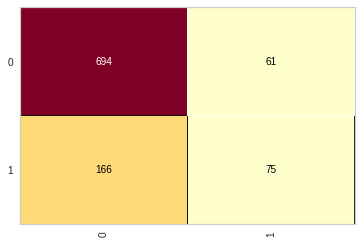

In [ ]:
cm = ConfusionMatrix(naive_credit_data)
cm.fit(X_credit_treinamento, y_credit_treinamento)
cm.score(X_credit_teste, y_credit_teste)

In [ ]:
#0 = clientes que pagam
#1 = clientes que não pagam

In [ ]:
print(classification_report(y_credit_treinamento, previsoes_treinamento))

              precision    recall  f1-score   support

           0       0.82      0.93      0.87      2976
           1       0.66      0.38      0.48      1006

    accuracy                           0.79      3982
   macro avg       0.74      0.65      0.67      3982
weighted avg       0.78      0.79      0.77      3982



In [ ]:
print(classification_report(y_credit_teste, previsoes_teste))
#recall -> consegue identificar corretamente o cliente em....
#precision -> é quando ele consegue identificar o cliente (recall, ele tem uma precisão de... )
#suport -> é os registros

              precision    recall  f1-score   support

           0       0.81      0.92      0.86       755
           1       0.55      0.31      0.40       241

    accuracy                           0.77       996
   macro avg       0.68      0.62      0.63       996
weighted avg       0.75      0.77      0.75       996



**Regressão Logística (RL) - 79,00%**

In [ ]:
import pickle
with open('credit.pkl', 'rb') as f:
  X_credit_treinamento, y_credit_treinamento, X_credit_teste, y_credit_teste = pickle.load(f)

In [ ]:
rl = LogisticRegression()

In [ ]:
rl = LogisticRegression(random_state=24)
rl.fit(X_credit_treinamento, y_credit_treinamento)

LogisticRegression(random_state=24)

In [ ]:
previsoes_treinamento = rl.predict(X_credit_treinamento)
previsoes_treinamento

array([1, 0, 0, ..., 1, 0, 0])

In [ ]:
y_credit_treinamento

array([1, 0, 0, ..., 0, 0, 0])

In [ ]:
#resultados previstos
previsoes_teste = rl.predict(X_credit_teste)
previsoes_teste

array([0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,

In [ ]:
#valores reais
y_credit_teste

array([0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,

In [ ]:
#quantos acertos e quantos erros ocorreram em %
accuracy_score(y_credit_treinamento, previsoes_treinamento)

0.8134103465595178

In [ ]:
#qauntos acertos e quantos erros ocorreram em %
accuracy_score(y_credit_teste, previsoes_teste)

0.7961847389558233

0.7961847389558233

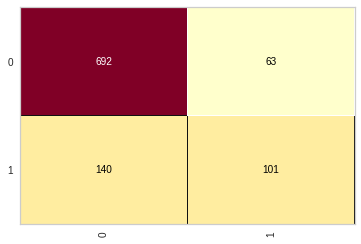

In [ ]:
cm = ConfusionMatrix(rl)
cm.fit(X_credit_treinamento, y_credit_treinamento)
cm.score(X_credit_teste, y_credit_teste)

In [ ]:
# 0 = clientes que pagam
# 1 = clientes que não pagam

In [ ]:
print(classification_report(y_credit_treinamento, previsoes_treinamento))

              precision    recall  f1-score   support

           0       0.84      0.93      0.88      2976
           1       0.69      0.47      0.56      1006

    accuracy                           0.81      3982
   macro avg       0.77      0.70      0.72      3982
weighted avg       0.80      0.81      0.80      3982



In [ ]:
print(classification_report(y_credit_teste, previsoes_teste))
#recall -> consegue identificar corretamente o cliente em....
#precision -> é quando ele consegue identificar o cliente (recall, ele tem uma precisão de... )
#suport -> é os registros

              precision    recall  f1-score   support

           0       0.83      0.92      0.87       755
           1       0.62      0.42      0.50       241

    accuracy                           0.80       996
   macro avg       0.72      0.67      0.69       996
weighted avg       0.78      0.80      0.78       996



**Máquina de Vetores de Suporte (SVM) - 79%**

In [ ]:
import pickle
with open('credit.pkl', 'rb') as f:
  X_credit_treinamento, y_credit_treinamento, X_credit_teste, y_credit_teste = pickle.load(f)

In [ ]:
X_credit_treinamento.shape, y_credit_treinamento.shape

((3982, 6), (3982,))

In [ ]:
X_credit_teste.shape, y_credit_teste.shape

((996, 6), (996,))

In [ ]:
#Podemos chegar em resultados melhores se mudarmos os parâmetros -> poly,Linear,sigmoid,rbf,precomputed
svm_credit = SVC(kernel='rbf', random_state=24, C = 2.0)
svm_credit.fit(X_credit_treinamento, y_credit_treinamento)

SVC(C=2.0, random_state=24)

In [ ]:
#resultados previstos
previsoes_treinamento = svm_credit.predict(X_credit_treinamento)
previsoes_treinamento

array([1, 0, 0, ..., 1, 0, 0])

In [ ]:
#valores reais
y_credit_treinamento

array([1, 0, 0, ..., 0, 0, 0])

In [ ]:
#resultados previstos
previsoes_teste = svm_credit.predict(X_credit_teste)
previsoes_teste

array([0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [ ]:
#valores reais
y_credit_teste

array([0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,

In [ ]:
accuracy_score(y_credit_treinamento, previsoes_treinamento)

0.8033651431441486

In [ ]:
accuracy_score(y_credit_teste, previsoes_teste)

0.7941767068273092

0.7941767068273092

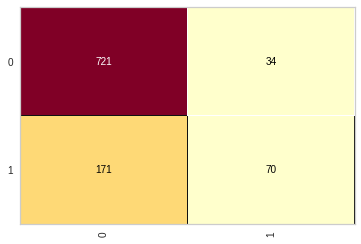

In [ ]:
cm = ConfusionMatrix(svm_credit)
cm.fit(X_credit_treinamento, y_credit_treinamento)
cm.score(X_credit_teste, y_credit_teste)

In [ ]:
#0 = clientes que pagam
#1 = clientes que não pagam

In [ ]:
print(classification_report(y_credit_treinamento, previsoes_treinamento))
#recall -> consegue identificar corretamente o cliente em....
#precision -> é quando ele consegue identificar o cliente (recall, ele tem uma precisão de... )
#suport -> é os registros

              precision    recall  f1-score   support

           0       0.81      0.97      0.88      2976
           1       0.76      0.32      0.45      1006

    accuracy                           0.80      3982
   macro avg       0.79      0.64      0.67      3982
weighted avg       0.80      0.80      0.77      3982



In [ ]:
print(classification_report(y_credit_teste, previsoes_teste))
#recall -> consegue identificar corretamente o cliente em....
#precision -> é quando ele consegue identificar o cliente (recall, ele tem uma precisão de... )
#suport -> é os registros

              precision    recall  f1-score   support

           0       0.81      0.95      0.88       755
           1       0.67      0.29      0.41       241

    accuracy                           0.79       996
   macro avg       0.74      0.62      0.64       996
weighted avg       0.78      0.79      0.76       996



**Modelo de Regressão - Exercício de Preço de Casas**

In [ ]:
import sys
assert sys.version_info >= (3, 5)
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sklearn
assert sklearn.__version__ >= "0.20"
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import mean_absolute_error
import statsmodels.formula.api as smf
import os
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

/usr/local/lib/python3.7/dist-packages/statsmodels/tools/_testing.py:19: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


In [ ]:
import os
import tarfile
import urllib.request

DOWNLOAD_ROOT = "https://raw.githubusercontent.com/ageron/handson-ml2/master/"
HOUSING_PATH = os.path.join("datasets", "housing")
HOUSING_URL = DOWNLOAD_ROOT + "datasets/housing/housing.tgz"

def fetch_housing_data(housing_url=HOUSING_URL, housing_path=HOUSING_PATH):
    if not os.path.isdir(housing_path):
        os.makedirs(housing_path)
    tgz_path = os.path.join(housing_path, "housing.tgz")
    urllib.request.urlretrieve(housing_url, tgz_path)
    housing_tgz = tarfile.open(tgz_path)
    housing_tgz.extractall(path=housing_path)
    housing_tgz.close()

In [ ]:
fetch_housing_data()

In [ ]:
import pandas as pd
def load_housing_data(housing_path=HOUSING_PATH):
    csv_path = os.path.join(housing_path, "housing.csv")
    return pd.read_csv(csv_path)

In [ ]:
housing = load_housing_data()

In [ ]:
housing.info()
housing.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [ ]:
housing.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [ ]:
housing.loc[pd.isnull(housing['total_bedrooms'])]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
290,-122.16,37.77,47.0,1256.0,NaN,570.0,218.0,4.3750,161900.0,NEAR BAY
341,-122.17,37.75,38.0,992.0,NaN,732.0,259.0,1.6196,85100.0,NEAR BAY
538,-122.28,37.78,29.0,5154.0,NaN,3741.0,1273.0,2.5762,173400.0,NEAR BAY
563,-122.24,37.75,45.0,891.0,NaN,384.0,146.0,4.9489,247100.0,NEAR BAY
696,-122.10,37.69,41.0,746.0,NaN,387.0,161.0,3.9063,178400.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20267,-119.19,34.20,18.0,3620.0,NaN,3171.0,779.0,3.3409,220500.0,NEAR OCEAN
20268,-119.18,34.19,19.0,2393.0,NaN,1938.0,762.0,1.6953,167400.0,NEAR OCEAN
20372,-118.88,34.17,15.0,4260.0,NaN,1701.0,669.0,5.1033,410700.0,<1H OCEAN
20460,-118.75,34.29,17.0,5512.0,NaN,2734.0,814.0,6.6073,258100.0,<1H OCEAN


In [ ]:
housing['total_bedrooms'].fillna(housing['total_bedrooms'].mean(), inplace = True)

In [ ]:
housing.loc[pd.isnull(housing['total_bedrooms'])]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity


In [ ]:
housing.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

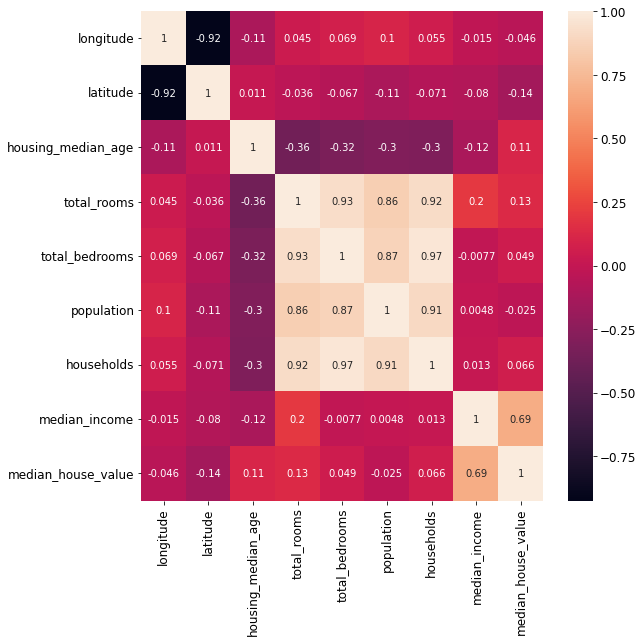

In [ ]:
figura = plt.figure(figsize=(9,9))
sns.heatmap(housing.corr(), annot=True);

**Regressão Multiplia**

In [ ]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
#x = Housing_media_age + total_bedrooms + total_rooms + households + median_income
#y = median_house_value

In [ ]:
X_casas = housing.loc[:,['households', 'total_rooms', 'total_bedrooms', 'housing_median_age', 'median_income', 'population']].values
X_casas

array([[1.2600e+02, 8.8000e+02, 1.2900e+02, 4.1000e+01, 8.3252e+00,
        3.2200e+02],
       [1.1380e+03, 7.0990e+03, 1.1060e+03, 2.1000e+01, 8.3014e+00,
        2.4010e+03],
       [1.7700e+02, 1.4670e+03, 1.9000e+02, 5.2000e+01, 7.2574e+00,
        4.9600e+02],
       ...,
       [4.3300e+02, 2.2540e+03, 4.8500e+02, 1.7000e+01, 1.7000e+00,
        1.0070e+03],
       [3.4900e+02, 1.8600e+03, 4.0900e+02, 1.8000e+01, 1.8672e+00,
        7.4100e+02],
       [5.3000e+02, 2.7850e+03, 6.1600e+02, 1.6000e+01, 2.3886e+00,
        1.3870e+03]])

In [ ]:
y_casas = housing.iloc[:, 8].values
y_casas

array([452600., 358500., 352100., ...,  92300.,  84700.,  89400.])

In [ ]:
from sklearn.model_selection import train_test_split
X_casas_treinamento, X_casas_teste, y_casas_treinamento, y_casas_teste = train_test_split(X_casas, y_casas, test_size = 0.20, random_state = 24)

In [ ]:
#serparação em treino e teste
X_casas_treinamento.shape, y_casas_treinamento.shape

((16512, 6), (16512,))

In [ ]:
X_casas_teste.shape, y_casas_teste.shape

((4128, 6), (4128,))

Regressão Treino

In [ ]:
#realizando o treinamento
regressor_multiplo_casas = LinearRegression()
regressor_multiplo_casas.fit(X_casas_treinamento, y_casas_treinamento)

LinearRegression()

In [ ]:
#b0
regressor_multiplo_casas.intercept_

-46544.484718870954

In [ ]:
#b1
regressor_multiplo_casas.coef_

array([ 1.44685374e+02, -1.83553763e+01,  7.75241210e+01,  1.92176678e+03,
        4.72138043e+04, -3.52445331e+01])

In [ ]:
#quantidade de atributos previsores
len(regressor_multiplo_casas.coef_)

6

In [ ]:
#Acertos
regressor_multiplo_casas.score(X_casas_treinamento, y_casas_treinamento)

0.5624227011155825

In [ ]:
#valores previstos - treino
previsoes_treino = regressor_multiplo_casas.predict(X_casas_treinamento)
previsoes_treino

array([157451.96029979, 141367.82777629, 286195.83219268, ...,
       199046.61618956, 246021.00297736, 200233.05563751])

In [ ]:
#valores reais - treino
y_casas_treinamento

array([160900., 106000., 343500., ..., 132500., 203200., 118800.])

In [ ]:
#Mean absolute error (MAE) - diferença entre o previsto e os valores reais
from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_casas_treinamento, previsoes_treino)
#quanto menor o erro, menor é a diferença entre a previsão e os valores reais

56035.580681047395

Regressão Teste

In [ ]:
regressor_multiplo_casas = LinearRegression()
regressor_multiplo_casas.fit(X_casas_teste, y_casas_teste)

LinearRegression()

In [ ]:
regressor_multiplo_casas.intercept_

-33990.71196355522

In [ ]:
regressor_multiplo_casas.coef_

array([ 1.84276663e+02, -1.80447709e+01,  5.33915101e+01,  1.63797900e+03,
        4.74379261e+04, -4.33017261e+01])

In [ ]:
regressor_multiplo_casas.score(X_casas_teste, y_casas_teste)

0.5797931179569114

In [ ]:
#valores previstos - teste
previsoes_teste = regressor_multiplo_casas.predict(X_casas_teste)
previsoes_teste

array([276340.17996198, 214661.44873597, 334377.07250651, ...,
       259700.2946705 , 231072.62081453,  78591.43670116])

In [ ]:
#valores reais - teste
y_casas_teste

array([235800.,  85700., 274000., ..., 196900., 192200.,  87800.])

In [ ]:
#Mean absolute error (MAE) - diferença entre o previsto e os valores reais
from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_casas_teste, previsoes_teste)
#quanto menor o erro, menor é a diferença entre a previsão e os valores reais

55570.35476531972

**Regressão Polinomial**

In [ ]:
X_casas_treinamento.shape

(16512, 6)

In [ ]:
X_casas_teste.shape

(4128, 6)

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree = 4)
X_casas_treinamento_poly = poly.fit_transform(X_casas_treinamento)
X_casas_teste_poly = poly.transform(X_casas_teste)

In [ ]:
X_casas_treinamento_poly.shape, X_casas_teste_poly.shape

((16512, 210), (4128, 210))

Regressão Treino

In [ ]:
regressor_casas_poly = LinearRegression()
regressor_casas_poly.fit(X_casas_treinamento_poly, y_casas_treinamento)

LinearRegression()

In [ ]:
regressor_casas_poly.score(X_casas_treinamento_poly, y_casas_treinamento)

0.6527514313460435

In [ ]:
previsoes_treinamento = regressor_casas_poly.predict(X_casas_treinamento_poly)
previsoes_treinamento

array([140144.50894018, 128165.38747607, 288168.22483317, ...,
       163239.0392887 , 256765.04389597, 146609.94879103])

In [ ]:
y_casas_treinamento

array([160900., 106000., 343500., ..., 132500., 203200., 118800.])

In [ ]:
#Mean absolute error (MAE) - diferença entre o previsto e os valores reais
from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_casas_treinamento, previsoes_treinamento)

49153.81194336049

Regressão Teste

In [ ]:
regressor_casas_poly = LinearRegression()
regressor_casas_poly.fit(X_casas_teste_poly, y_casas_teste)

LinearRegression()

In [ ]:
regressor_casas_poly.score(X_casas_teste_poly, y_casas_teste)

0.6924134363412305

In [ ]:
previsoes_teste = regressor_casas_poly.predict(X_casas_teste_poly)
previsoes_teste

array([299882.25400663, 197221.45751773, 328587.42771367, ...,
       243921.24441895, 187592.97224927,  67838.33067901])

In [ ]:
y_casas_teste

array([235800.,  85700., 274000., ..., 196900., 192200.,  87800.])

In [ ]:
#Mean absolute error (MAE) - diferença entre o previsto e os valores reais
from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_casas_teste, previsoes_teste)

47291.467184787485


**Regressão Random Florest**



In [ ]:
X_casas_treinamento.shape

(16512, 6)

In [ ]:
X_casas_treinamento

array([[4.7700e+02, 2.7930e+03, 4.7600e+02, 1.6000e+01, 3.4667e+00,
        1.2790e+03],
       [3.4500e+02, 1.4610e+03, 3.4100e+02, 3.0000e+01, 2.4667e+00,
        1.0140e+03],
       [4.6600e+02, 2.9620e+03, 4.6800e+02, 5.2000e+01, 4.9042e+00,
        1.3640e+03],
       ...,
       [7.3600e+02, 3.0690e+03, 7.5000e+02, 6.0000e+00, 3.8140e+00,
        1.5410e+03],
       [4.6700e+02, 2.3120e+03, 4.9600e+02, 2.8000e+01, 4.7135e+00,
        1.3440e+03],
       [1.2500e+03, 5.7730e+03, 1.3200e+03, 2.2000e+01, 2.5238e+00,
        2.6070e+03]])

In [ ]:
y_casas_treinamento

array([160900., 106000., 343500., ..., 132500., 203200., 118800.])

In [ ]:
X_casas_teste

array([[4.9200e+02, 3.0980e+03, 5.4200e+02, 2.3000e+01, 5.7613e+00,
        1.4860e+03],
       [1.0720e+03, 5.8970e+03, 1.1380e+03, 1.1000e+01, 4.1500e+00,
        2.7280e+03],
       [2.8600e+02, 1.9320e+03, 2.6600e+02, 2.1000e+01, 7.1497e+00,
        8.6000e+02],
       ...,
       [7.6300e+02, 3.9940e+03, 7.6400e+02, 3.3000e+01, 5.2308e+00,
        2.7210e+03],
       [2.2800e+02, 1.3240e+03, 2.1100e+02, 3.4000e+01, 4.5234e+00,
        7.9900e+02],
       [6.6300e+02, 3.2490e+03, 6.6600e+02, 2.1000e+01, 1.9423e+00,
        2.6110e+03]])

Regressão Treino

In [ ]:
regressor_random_forest_casas = RandomForestRegressor(n_estimators=100)
regressor_random_forest_casas.fit(X_casas_treinamento, y_casas_treinamento)

RandomForestRegressor()

In [ ]:
regressor_random_forest_casas.score(X_casas_treinamento, y_casas_treinamento)

0.9529779573225463

In [ ]:
previsoes_treinamento = regressor_random_forest_casas.predict(X_casas_treinamento)
previsoes_treinamento

array([155545.  , 129499.  , 328758.02, ..., 158054.  , 213710.  ,
       133078.  ])

In [ ]:
y_casas_treinamento

array([160900., 106000., 343500., ..., 132500., 203200., 118800.])

In [ ]:
#Mean absolute error (MAE) - diferença entre o previsto e os valores reais
from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_casas_treinamento, previsoes_treinamento)

17897.119313832365

Regressão Teste

In [ ]:
regressor_random_forest_casas = RandomForestRegressor(n_estimators=100)
regressor_random_forest_casas.fit(X_casas_teste, y_casas_teste)

RandomForestRegressor()

In [ ]:
regressor_random_forest_casas.score(X_casas_teste, y_casas_teste)

0.9495981607182842

In [ ]:
previsoes_teste = regressor_random_forest_casas.predict(X_casas_teste)
previsoes_teste

array([246341.01, 132319.  , 287582.01, ..., 209015.  , 220514.01,
        86767.  ])

In [ ]:
y_casas_teste

array([235800.,  85700., 274000., ..., 196900., 192200.,  87800.])

In [ ]:
#Mean absolute error (MAE) - diferença entre o previsto e os valores reais
from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_casas_teste, previsoes_teste)

18835.465467538757